In [2]:
from implementation import EnergyConservingDecompositionPass
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import PassManager
import numpy as np
from qiskit.circuit.library import UnitaryGate, CCZGate, CSwapGate, XXPlusYYGate, SGate, SdgGate
from qiskit.quantum_info import Operator

from qiskit.transpiler.passes import (
    Collect2qBlocks,
    ConsolidateBlocks,
    Optimize1qGatesDecomposition,
    CommutativeCancellation,
    UnitarySynthesis
)


def exp_i_theta_involution(A: np.ndarray, theta: float) -> np.ndarray:
    """
    Compute exp(i θ A) for a matrix A with A^2 = I.
    Uses: exp(i θ A) = cos θ I + i sin θ A
    """
    dim = A.shape[0]
    I = np.eye(dim, dtype=complex)
    return np.cos(theta) * I + 1j * np.sin(theta) * A


def add_exp_i_theta_swap(qc: QuantumCircuit, theta: float, q0: int, q1: int):
    """Append e^{i θ SWAP} acting on qubits (q0, q1)."""
    swap = np.array(
        [
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=complex,
    )
    U = exp_i_theta_involution(swap, theta)
    gate = UnitaryGate(U, label="$exp^{i\\theta \\; SWAP}$")
    qc.append(gate, [q0, q1])
    return qc

def add_controlled_exp_i_theta_swap(qc: QuantumCircuit, theta: float, control: int, q0: int, q1: int):
    """Append controlled e^{i θ SWAP} acting on qubits (q0, q1) with control qubit."""
    swap = np.array(
        [
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=complex,
    )
    U = exp_i_theta_involution(swap, theta)
    
    # Create controlled unitary gate
    controlled_U = UnitaryGate(U, label="$exp^{i\\theta \\; SWAP}$").control()
    qc.append(controlled_U, [control, q0, q1])
    return qc

def add_exp_i_theta_swap_kron_swap(qc: QuantumCircuit, theta: float, q0: int, q1: int, q2: int, q3: int):
    """Append e^{i θ (SWAP ⊗ SWAP)} on qubits (q0,q1,q2,q3)."""
    swap = np.array(
        [
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=complex,
    )
    swap_kron = np.kron(swap, swap)  # SWAP ⊗ SWAP
    U = exp_i_theta_involution(swap_kron, theta)
    gate = UnitaryGate(U, label="$exp^{i\\theta \\; SWAP\\otimes SWAP}$")
    qc.append(gate, [q0, q1, q2, q3])
    return qc


def add_CCZ(qc: QuantumCircuit, q0: int, q1: int, q2: int):
    """Append a CCZ gate on (q0, q1, q2)."""
    qc.append(CCZGate(), [q0, q1, q2])
    return qc


def add_CSWAP(qc: QuantumCircuit, qc0: int, q1: int, q2: int):
    """Append a CSWAP (Fredkin) gate on (control, target1, target2)."""
    qc.append(CSwapGate(), [qc0, q1, q2])
    return qc


def add_exp_i_theta_CSWAP(qc: QuantumCircuit, theta: float, qc0: int, q1: int, q2: int):
    """Append e^{i θ CSWAP} on (control, target1, target2)."""
    # Build the CSWAP matrix once using a small auxiliary circuit
    aux = QuantumCircuit(3)
    aux.cswap(0, 1, 2)
    cswap_matrix = Operator(aux).data  # 8x8

    U = exp_i_theta_involution(cswap_matrix, theta)
    gate = UnitaryGate(U, label="$exp^{i\\theta \\;CSWAP}$")
    qc.append(gate, [qc0, q1, q2])
    return qc


def add_Ry_hw1(qc: QuantumCircuit, theta: float, qubits: list[int]):
    """Apply Ry(θ) to each qubit in qubits."""
    qc.append(SdgGate(), [qubits[0]])
    qc.append(XXPlusYYGate(theta), qubits)
    qc.append(SGate(), [qubits[0]])
    return qc

def get_standrad_vs_ec_decompositions(qc: QuantumCircuit):
    pm = PassManager([
        # Collect2qBlocks(),
        # ConsolidateBlocks(),
        UnitarySynthesis(basis_gates=['rz', 'cx']),
        Optimize1qGatesDecomposition(),
        CommutativeCancellation(),
    ])
    
    ec_pm = PassManager([
        EnergyConservingDecompositionPass(),
        # Collect2qBlocks(),
        # ConsolidateBlocks(),
        Optimize1qGatesDecomposition(),
        CommutativeCancellation(),
    ])
    
    qc_decomposed = pm.run(qc)
    qc_ec_decomposed = ec_pm.run(qc)
    
    
    return qc_decomposed, qc_ec_decomposed

Original circuit:


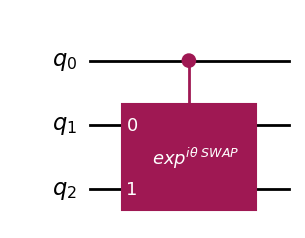

In [3]:
qc = QuantumCircuit(3)

# Add some test SWAP gates on arbitrary qubit pairs
theta = np.pi /4

# add_exp_i_theta_swap(qc, theta, 0, 1)
# add_exp_i_theta_swap(qc, theta, 2, 3)
# add_exp_i_theta_swap(qc, theta, 1, 3)

add_controlled_exp_i_theta_swap(qc, theta, 0, 1, 2)

# 2) e^{i θ (SWAP ⊗ SWAP)} on (0,1,2,3)
# add_exp_i_theta_swap_kron_swap(qc, theta/2, 0, 1, 2, 3)
# add_exp_i_theta_swap_kron_swap(qc, theta*3/4, 0, 1, 4, 5)
# add_exp_i_theta_swap_kron_swap(qc, theta*2, 4, 1, 2, 5)

# 3) CCZ on (0, 2, 3)
# add_CCZ(qc, 0, 1, 2)

# 4) CSWAP with control=0, targets=(3,4)
# add_CSWAP(qc, 0, 1, 2)

# 5) e^{i θ CSWAP} on (0,3,4)
# add_exp_i_theta_CSWAP(qc, theta, 0, 3, 4)


print("Original circuit:")
display(qc.draw("mpl"))

Gates count comparison:
Gates Count Before: OrderedDict({'c-unitary': 1})
Gates Count After Standard Decomposition: OrderedDict({'c-unitary': 1})
Gates Count After EC Decomposition: OrderedDict({'sqrtiSWAP_ec': 216, 'sqrtiSWAPdg_ec': 216, 'rz': 104, 's': 90, 'sdg': 90})


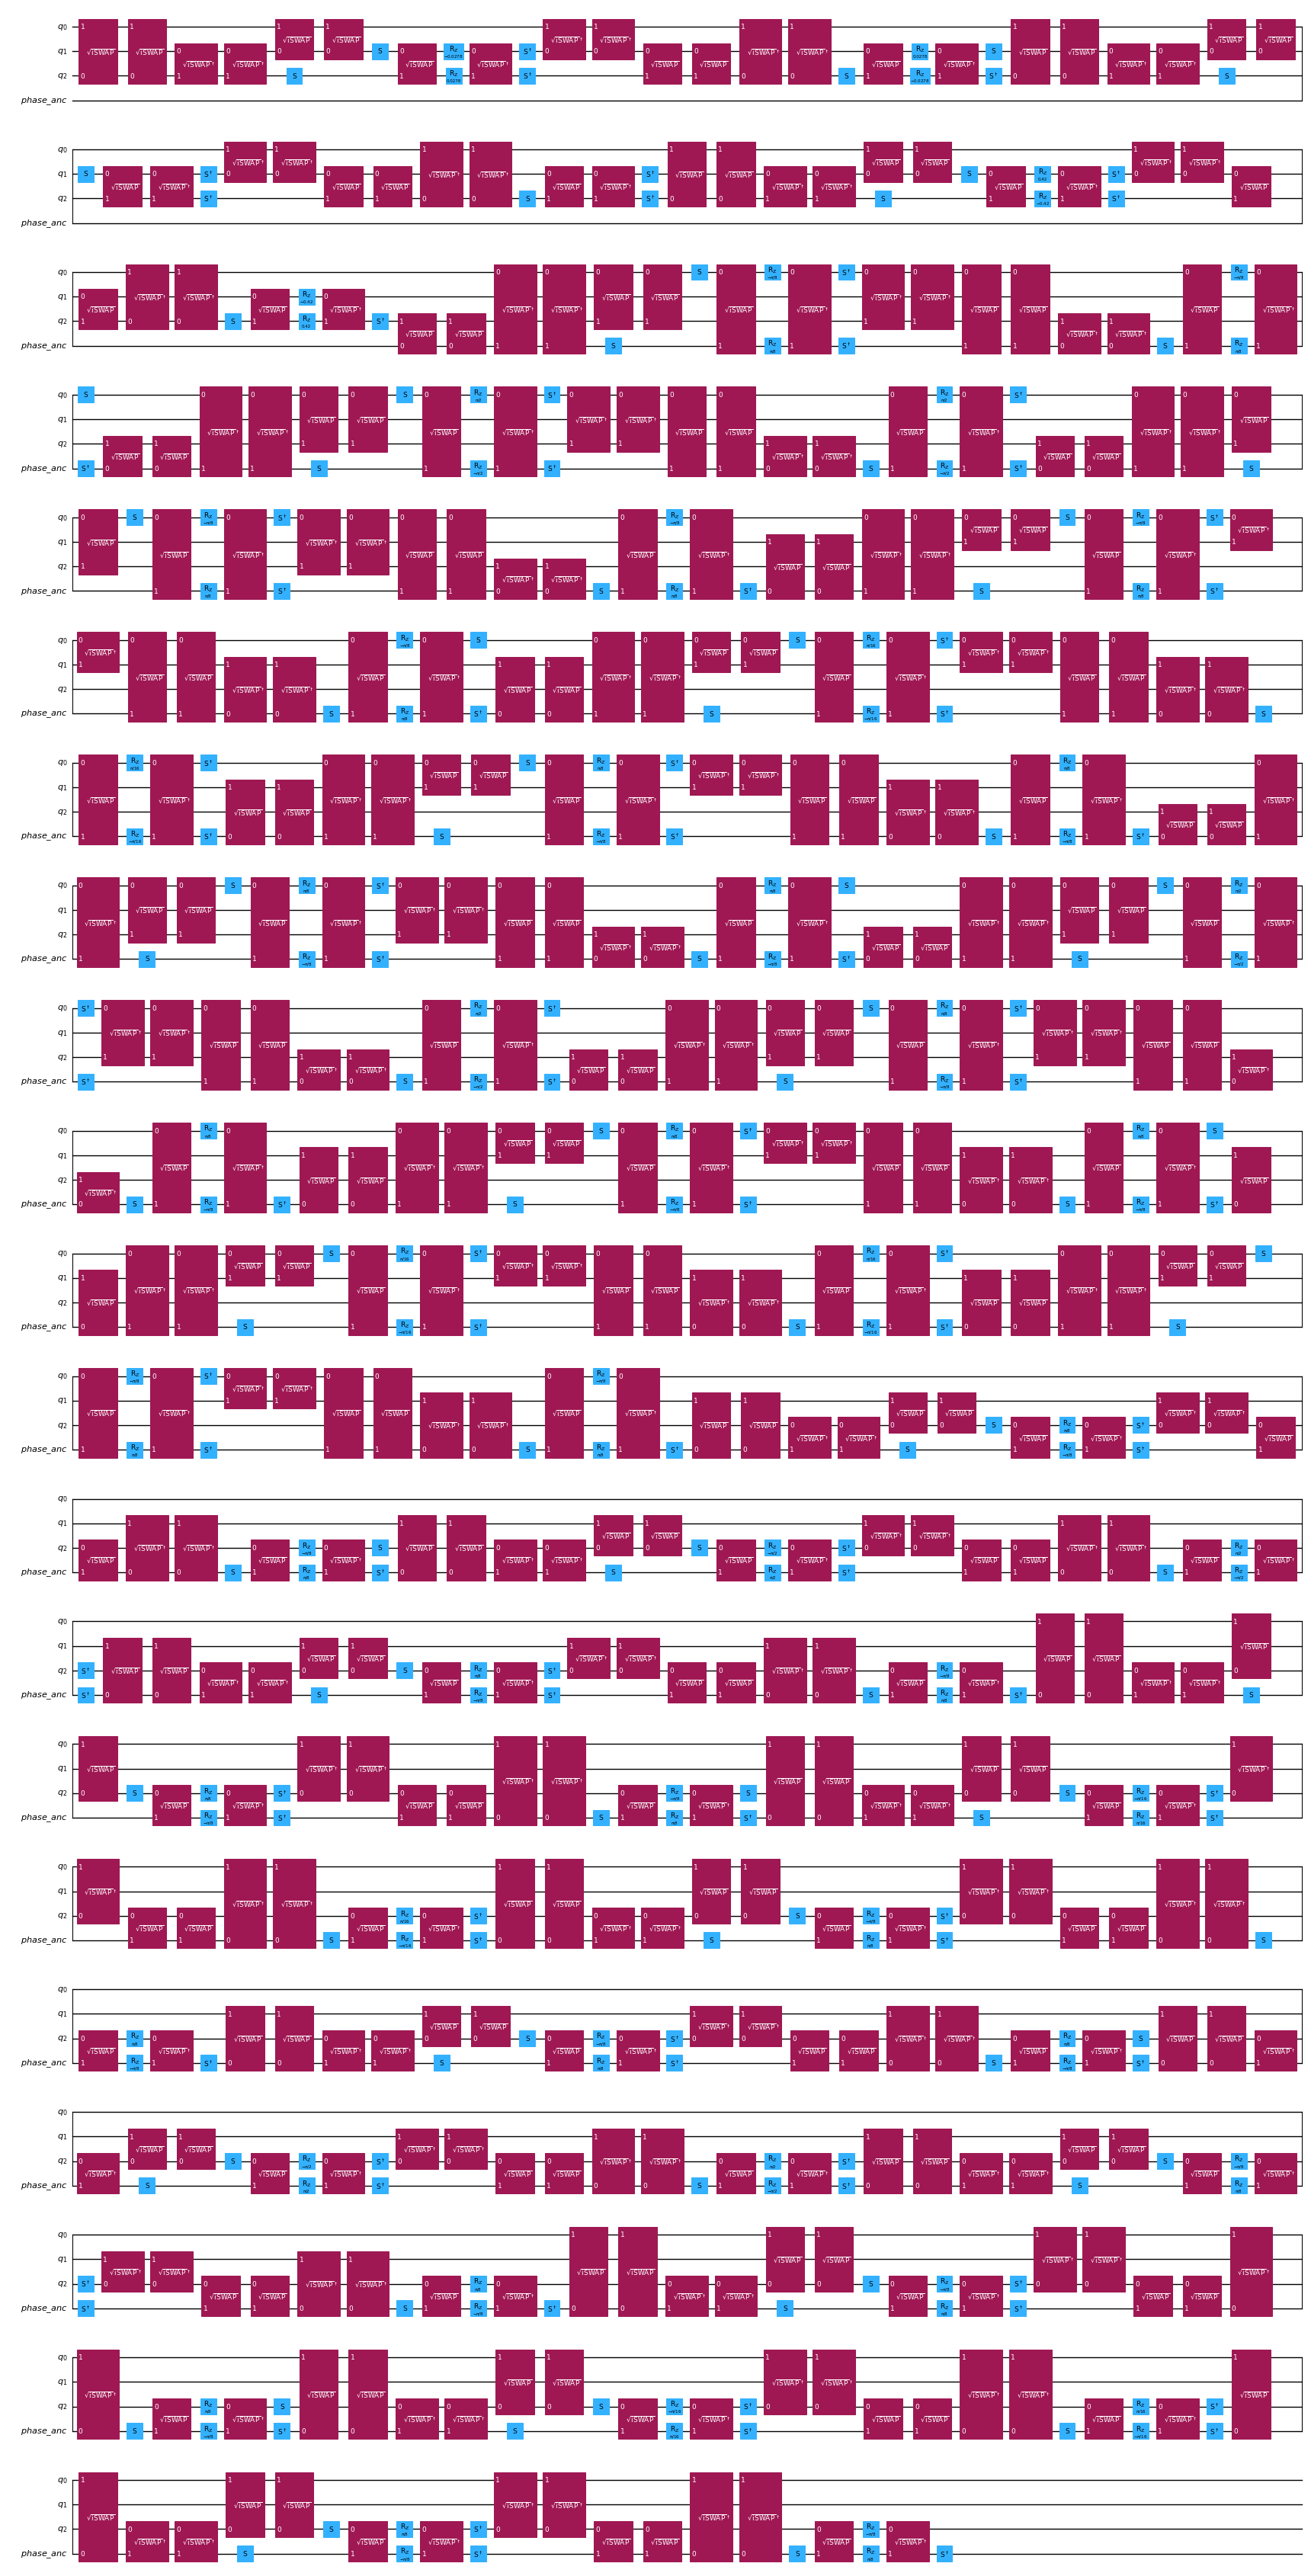

In [4]:
qc_decomposed, qc_ec_decomposed = get_standrad_vs_ec_decompositions(qc)
print("Gates count comparison:")
print(f"Gates Count Before: {qc.count_ops()}")
print(f"Gates Count After Standard Decomposition: {qc_decomposed.count_ops()}")
print(f"Gates Count After EC Decomposition: {qc_ec_decomposed.count_ops()}")

display(qc_ec_decomposed.draw("mpl", scale=0.5, fold=50))

In [5]:
from implementation import get_effective_unitary, print_nontrivial_unitary_basis_action, _unitaries_close_up_to_phase
from qiskit.quantum_info import Operator

U_original = Operator(qc).data
U_original = U_original * np.exp(-1j * np.angle(U_original[0, 0]))

qc_decomposed = qc_ec_decomposed
U_decomp = Operator(qc_decomposed).data
U_decomp_eff = get_effective_unitary(qc_decomposed, [qc.num_qubits], 0)

_unitaries_close_up_to_phase(U_original, U_decomp_eff)

True